# Etapa 2 del proyecto: Hacia una medicina preventiva en hipertensión arterial

La hipertensión arterial es uno de los principales factores de riesgo para las enfermedades cardiovasculares, las cuales, a su vez, son una de las causas principales de morbilidad y mortalidad a nivel mundial[1]. La detección temprana de esta afección representa un gran reto, ya que sus síntomas a menudo pasan desapercibidos y el diagnóstico se realiza con frecuencia en etapas avanzadas. Esta situación resalta la importancia de encontrar soluciones que apoyen en la identificación precoz de la hipertensión.

Este proyecto tiene como objetivo desarrollar modelos predictivos basados en datos que permitan estimar el riesgo de hipertensión en pacientes. **La finalidad es doble**: por un lado, facilitar la identificación temprana de casos y, por otro, identificar los factores clave que influyen en el desarrollo de la enfermedad. Una herramienta de este tipo sería de gran valor para los profesionales de la salud ya que les permitiría fortalecer las campañas y programas de prevención, así como diseñar estrategias de educación en salud más personalizadas.


Con el contexto del problema podemos evidenciar que debemos:
- **desarrollar modelos predictivos**
- **que permitan estimar**
- **el riesgo de hipertensión en pacientes**

Para:
- **facilitar la identificación temprana**
- **dentificar los factores clave que influyen en el desarrollo de la enfermedad**


In [60]:
#Importacíón de librerias:

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from importlib.metadata import version
from ydata_profiling import ProfileReport


from importlib.metadata import version

print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Matplotlib: {version('matplotlib')}")
print(f"Versión de Scikit-learn: {version('scikit-learn')}")
print(f"Versión de Numpy: {version('numpy')}")
print(f"Versión de ydata_profiling: {version('ydata_profiling')}")

Versión de Pandas: 2.3.3
Versión de Matplotlib: 3.10.0
Versión de Scikit-learn: 1.8.0
Versión de Numpy: 2.1.3
Versión de ydata_profiling: 4.18.0


!pip show sweetviz

# **1. Exploración y perfilamiento de los datos**

In [61]:
ruta = "./Data/Datos_hipertension.csv"
data_raw = pd.read_csv(ruta, sep=";" , encoding="latin1")

Al intentar cargar los datos generó un error ya que contiene valores con tilde como por ejemmplo las variables "Medicación" es por eso que se usa el encoding "Latin1"

In [62]:
data_raw.head()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon,Hipertension
0,69,8.0,9,242.4,6.4,25.8,Ninguna,Si,Baja,No,127.8,Si,Si
1,32,11.7,10,177.2,5.4,23.4,Ninguna,No,Baja,No,105.9,No,No
2,78,9.5,3,193.0,7.1,18.7,Ninguna,No,Moderada,No,102.7,No,No
3,38,10.0,10,268.1,4.2,22.1,InhibidorACE,No,Baja,No,99.0,No,Si
4,41,9.8,1,175.3,5.8,16.2,Otro,No,Moderada,No,101.5,No,No


In [92]:
data = data_raw.copy()

In [64]:
data.head()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon,Hipertension
0,69,8.0,9,242.4,6.4,25.8,Ninguna,Si,Baja,No,127.8,Si,Si
1,32,11.7,10,177.2,5.4,23.4,Ninguna,No,Baja,No,105.9,No,No
2,78,9.5,3,193.0,7.1,18.7,Ninguna,No,Moderada,No,102.7,No,No
3,38,10.0,10,268.1,4.2,22.1,InhibidorACE,No,Baja,No,99.0,No,Si
4,41,9.8,1,175.3,5.8,16.2,Otro,No,Moderada,No,101.5,No,No


## Revisión de  datos nulos y duplicados:

In [65]:
data.isna().sum()

Edad                  0
Ingesta_Sal           0
Nivel_Stres           0
Colesterol            0
Duración_Sueño        0
BMI                   0
Medicación            0
Historia_Familiar     0
Actividad_Fisica      0
Fumador               0
Glucosa               0
Enfermedad_Corazon    0
Hipertension          0
dtype: int64

In [131]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1986 entries, 0 to 1989
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Edad                1986 non-null   int64  
 1   Ingesta_Sal         1986 non-null   float64
 2   Nivel_Stres         1986 non-null   int64  
 3   Colesterol          1986 non-null   float64
 4   Duración_Sueño      1986 non-null   float64
 5   BMI                 1986 non-null   float64
 6   Medicación          1986 non-null   object 
 7   Historia_Familiar   1986 non-null   object 
 8   Actividad_Fisica    1986 non-null   object 
 9   Fumador             1986 non-null   object 
 10  Glucosa             1986 non-null   float64
 11  Enfermedad_Corazon  1986 non-null   object 
 12  Hipertension        1986 non-null   object 
dtypes: float64(5), int64(2), object(6)
memory usage: 281.8+ KB


<div style="
background:#d3f9d8;
border-left:6px solid #2b8a3e;
padding:16px;
border-radius:8px;
margin:12px 0;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#1b5e20;">✔ Resultado</b><br>
Al ejecutar el análisis se observa que el dataset no contiene valores faltantes. No hay varoles nulos entonces no se requiere imputación

</div>

In [93]:
data.duplicated().sum()

np.int64(4)

In [94]:
data = data.drop_duplicates()

In [95]:
data.shape

(1986, 13)

<div style="
background:#ffe3e3;
border-left:6px solid #c92a2a;
padding:16px;
border-radius:8px;
margin:12px 0;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#a51111;">✖ Problema detectado</b><br>
Se encontraron registros duplicados que deben ser tratados antes de entrenar el modelo.
Se eliminan de una vez.

</div>

## División de los datos en Train y Test:

Realizo de una vez la divisón para no ver nada del test y realizar posteriormente un análisis de los datos solo con train.

In [ ]:
train, test = train_test_split(data, test_size=0.2, random_state=77, stratify=data['Hipertension'])

Aqui uso `stratify` para que en la separación mi variable objetivo se mantenga en iguales proporciones

In [96]:
X_train = train.drop(['Hipertension'], axis=1)
y_train = train['Hipertension']

X_test = test.drop(['Hipertension'],axis=1)
y_test = test['Hipertension']

In [100]:
X_train,y_train

(      Edad  Ingesta_Sal  Nivel_Stres  Colesterol  Duración_Sueño   BMI  \
 1444    37          6.7            3       194.7             8.6  21.1   
 1917    34          9.9            2       192.8             4.8  21.4   
 342     75          7.3            2       209.4             5.9  35.2   
 740     50          6.8            7       213.3             4.5  22.5   
 1706    49          6.5            0       189.8             5.7  21.0   
 ...    ...          ...          ...         ...             ...   ...   
 1320    51          7.6            0       158.7             8.7  25.7   
 236     68          8.0            1       283.6             6.0  33.9   
 1624    36          6.8            8       203.0             4.2  25.1   
 608     21          7.5            0       164.5             8.0  27.1   
 728     43          9.5            9       180.4             5.9  32.8   
 
           Medicación Historia_Familiar Actividad_Fisica Fumador  Glucosa  \
 1444  BloqueadorBeta

## **Perfilamiento de los datos**:

### Verificación de valores unicos, tipos de datos, tipo de variable:

In [107]:
resumen = pd.DataFrame({
    'tipo_dtype': train.dtypes,
    'num_unicos': train.nunique(),
    'ejemplo_valores': [train[col].dropna().unique()[:6].tolist() for col in train.columns],
    'min': train.select_dtypes(include=['int64', 'float64']).min().reindex(train.columns),
    'max': train.select_dtypes(include=['int64', 'float64']).max().reindex(train.columns),
    'Tipo_variable': [
        'Binaria' if train[col].nunique() == 2
        else 'Categórica' if train[col].nunique() <= 10
        else 'Numérica '
        for col in train.columns
    ]
})
resumen

,tipo_dtype,num_unicos,ejemplo_valores,min,max,Tipo_variable
Edad,int64,67,"[37, 34, 75, 50, 49, 39]",18.0,84.0,Numérica
Ingesta_Sal,float64,117,"[6.7, 9.9, 7.3, 6.8, 6.5, 7.5]",2.5,16.4,Numérica
Nivel_Stres,int64,11,"[3, 2, 7, 0, 4, 5]",0.0,10.0,Numérica
Colesterol,float64,905,"[194.7, 192.8, 209.4, 213.3, 189.8, 235.4]",121.2,2360.0,Numérica
Duración_Sueño,float64,86,"[8.6, 4.8, 5.9, 4.5, 5.7, 9.6]",1.5,11.4,Numérica
BMI,float64,231,"[21.1, 21.4, 35.2, 22.5, 21.0, 28.1]",11.9,41.3,Numérica
Medicación,object,5,"[BloqueadorBeta, InhibidorACE, Ninguna, Diuret...",NaN,NaN,Categórica
Historia_Familiar,object,2,"[No, Si]",NaN,NaN,Binaria
Actividad_Fisica,object,3,"[Alta, Baja, Moderada]",NaN,NaN,Categórica
Fumador,object,2,"[No, Si]",NaN,NaN,Binaria


<class 'pandas.core.frame.DataFrame'>
Index: 1986 entries, 0 to 1989
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Edad                1986 non-null   int64  
 1   Ingesta_Sal         1986 non-null   float64
 2   Nivel_Stres         1986 non-null   int64  
 3   Colesterol          1986 non-null   float64
 4   Duración_Sueño      1986 non-null   float64
 5   BMI                 1986 non-null   float64
 6   Medicación          1986 non-null   object 
 7   Historia_Familiar   1986 non-null   object 
 8   Actividad_Fisica    1986 non-null   object 
 9   Fumador             1986 non-null   object 
 10  Glucosa             1986 non-null   float64
 11  Enfermedad_Corazon  1986 non-null   object 
 12  Hipertension        1986 non-null   object 
dtypes: float64(5), int64(2), object(6)
memory usage: 281.8+ KB


Al realizar un análisis de los datos, contrastando con el diccionario se puede ver concluir que:

- Todas las 6 variables númericas `(Edad, Nivel_Stres, BMI, Duración_sueño, Colesterol, Glucosa)` son acordes al diccionario.
- En el resultado del dataframe se observa una **septima** variable númerica, la cual corresponde a `ingesta de sal`. Esta variable es inconsistente con nuestro diccionario ya que debería ser `Categorica ordinal` y el tipo de datos deberìa ser `bajo,moderado,alto`, además no tenemos una manera de saber cuales son los rangos de valores núericos para cada categoria, por lo que para este caso se toma la decisión de eliminarla y no tomarla encuenta para el ejercicio, ademàs se consultò con el experto(foro) y se tomò la decisiòn de no utilizarla.
- La unica variable `Categorica Ordinal` sería entonces `actividad física` ya que tiene un orden de peso en sus categorias y se realizará un tratamiento de datos para convertirla a la forma **[0,1,2]**
- La única variable `Categórica Nominal` sería entonces `Medicación`
- La variable target `Hipertension` es correcta, ya que se observa que  es categorica y binaria(Solo tiene dos posible valores, si y no)
- También se detecta un valor max de `colesterol` mucho mayor que con respecto al conjunto de **ejemplo unicos**, revisará a continuación la revisión de Outliners.
- Las variables  `fumandor`, `Enfernedad_corazòn`, `Historia familiar` tiene datos correctós según lo esperado al revisar el diccionario.


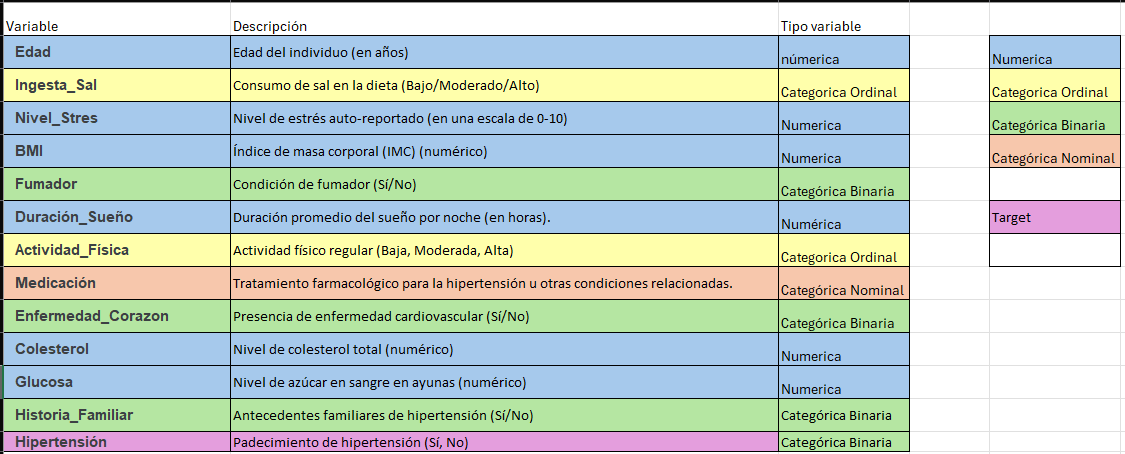

## Detección de Outliners:

In [109]:
numericas = ['Edad','Nivel_Stres','BMI','Duración_Sueño','Colesterol','Glucosa']
cat_Ordinal = ['Actividad_Fisica']
cat_binarias = ['Fumador','Enfermedad_Corazon','Historia_Familiar']
cat_nominal = ['Medicación']


En los siguientes Diagramas de Caja y Bigotes utilizaré el conjunto data para observar en todos los datos los outliners ya es muy probable que al realizar la división entre el conjunto train y test puede que los datos outliners hayan quedado unicamente en test por lo que me podrìa perjudicar a la hora de tomar una decisiòn, la cual implicaría `imputación`,`eliminación`,`estandarización` según sea el análisis de los outliners. Además de que justamente en este punto ya he realizado la división de los datos en train y test.

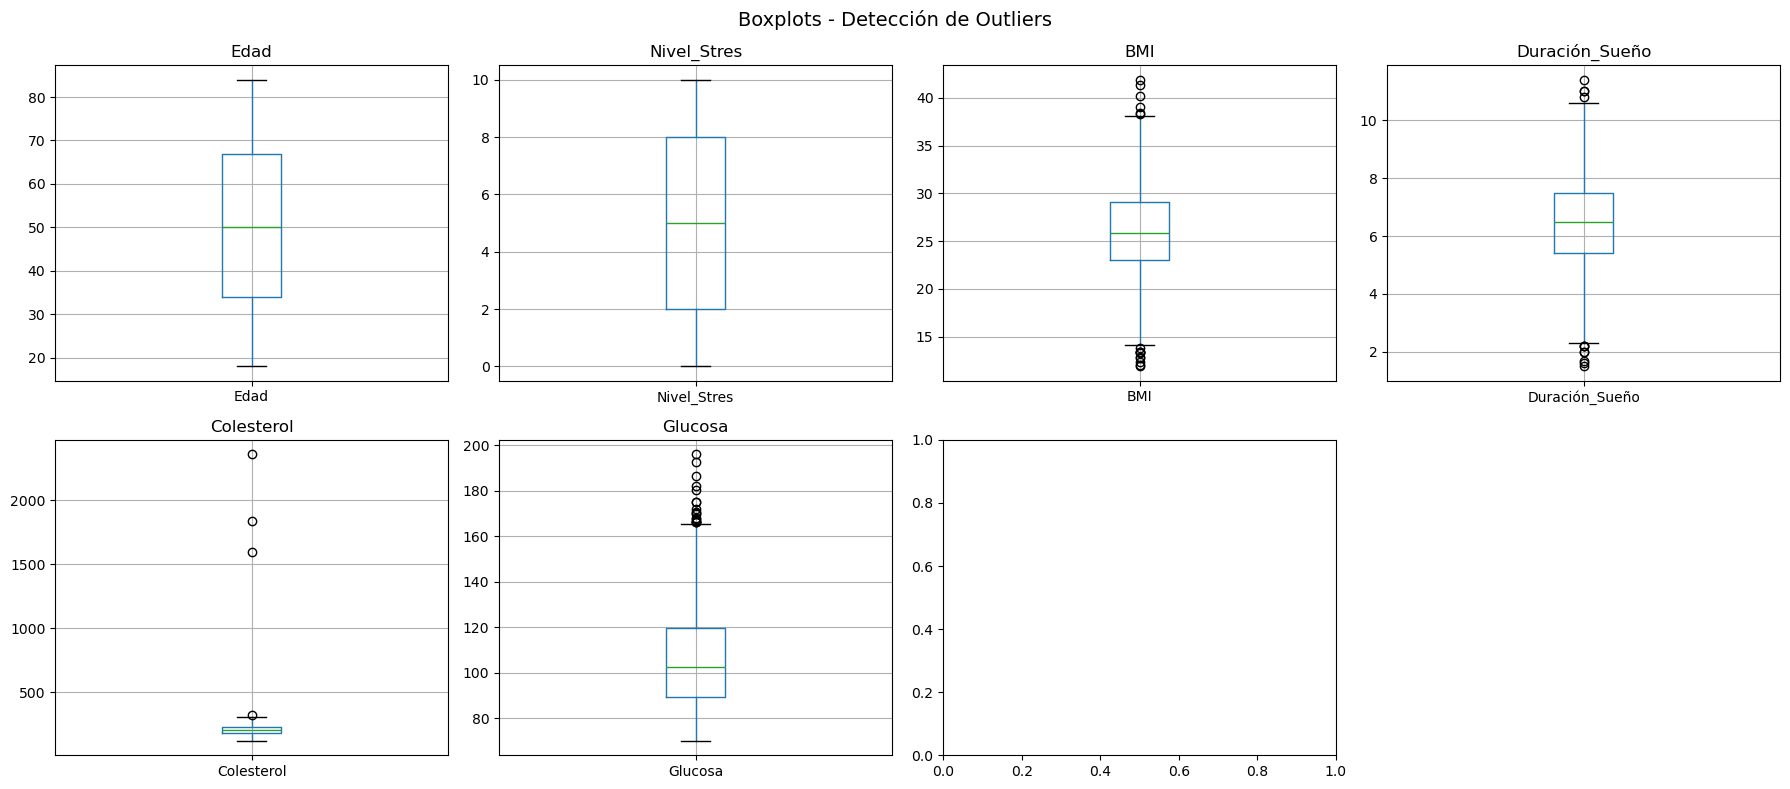

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(numericas):
    ax = axes[i // 4, i % 4]
    data.boxplot(column=col, ax=ax)
    ax.set_title(col)

axes[1, 3].axis('off')
plt.suptitle('Boxplots - Detección de Outliers', fontsize=14)
plt.tight_layout()
plt.show()

<div style="
background:#ffe3e3;
border-left:6px solid #c92a2a;
padding:16px;
border-radius:8px;
margin:12px 0;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#a51111;">✖ Problema detectado</b><br>
Como se puede observar, <b>BIM, duración sueño, colesterol y Glucosa</b>> tiene valores outliners
- Además de que se observan los mayores valores de outliners en <b>colesterol</b> con respecto a las diferencias que hay en las otras variables.

</div>

Aqui voy a mostrar explicitamente cual son esos valores outliners,  para entender la naturaleza de los datos para tomar una decisión:

In [128]:
# Ojo aqui tambíen usaré el conjunto data, pero solo para evidenciar todos los datos outliners y poder identificar posibles errores de digitación de datos
# en la etapa de Recolección de datos.
for col in numericas:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    if not outliers.empty:
        print(f"\n--- {col} ---")
        print(f"Rango válido: [{lower:.2f}, {upper:.2f}]")
        print(f"Outliers encontrados: {len(outliers)}")
        print(outliers[col].values)


--- BMI ---
Rango válido: [13.85, 38.25]
Outliers encontrados: 16
[13.4 12.  41.3 13.4 39.  12.8 40.2 11.9 41.9 13.3 13.4 13.8 38.3 12.9
 38.4 12.4]

--- Duración_Sueño ---
Rango válido: [2.25, 10.65]
Outliers encontrados: 12
[ 2.2 10.8  1.6  2.   2.2 11.   1.5 11.4  2.   1.7  2.2 11. ]

--- Colesterol ---
Rango válido: [105.70, 307.30]
Outliers encontrados: 4
[2360.  1597.  1835.   326.3]

--- Glucosa ---
Rango válido: [43.19, 165.89]
Outliers encontrados: 17
[175.3 192.7 166.4 180.5 182.3 170.5 175.3 172.  186.7 166.7 167.4 168.1
 166.2 170.3 196.1 166.1 169.6]


<div style="
background:#ffe3e3;
border-left:6px solid #c92a2a;
padding:16px;
border-radius:8px;
margin:12px 0;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#a51111;">✖ Problema detectado</b><br>
Con lo anterior podemos observar que los outliners de <b>Colesterol </b> parecen datos mal digitados en la recolección de los mismos ya que clinicamente no es posible tener valores de <b>2360.  1597.  1835</b> S

Según las guías clínicas de la AHA/ACC (2018), el colesterol total normal es inferior a 200 mg/dL y se considera alto a partir de 240 mg/dL. Incluso en los casos más extremos documentados en la literatura médica, como la hipercolesterolemia familiar homocigota (NCBI Bookshelf, NIH), los niveles de LDL rara vez superan los 500 mg/dL. Se tomará la decisión de eliminar estos 3 registros con colesterol mayor a 500
Rerefencias consultadas: https://www.healthline.com/health/high-cholesterol/levels-by-age y https://pubmed.ncbi.nlm.nih.gov/2180270/

El resto de outliners sobre las otras variables son posibles y no son tan extremos como un BMI de 41.9 es obesidad severa pero real, una glucosa de 196 es alta pero posible en diabéticos, y dormir 1.5 horas es extremo pero no imposible. <b> No se eliminaran ni imputaran, solo se aplicará RobustScaler para el caso de KNN para que regule mejor estos datos</b>

</div>

## Distribución de variables categoricas:

En los siguientes apartados solo usaré el train

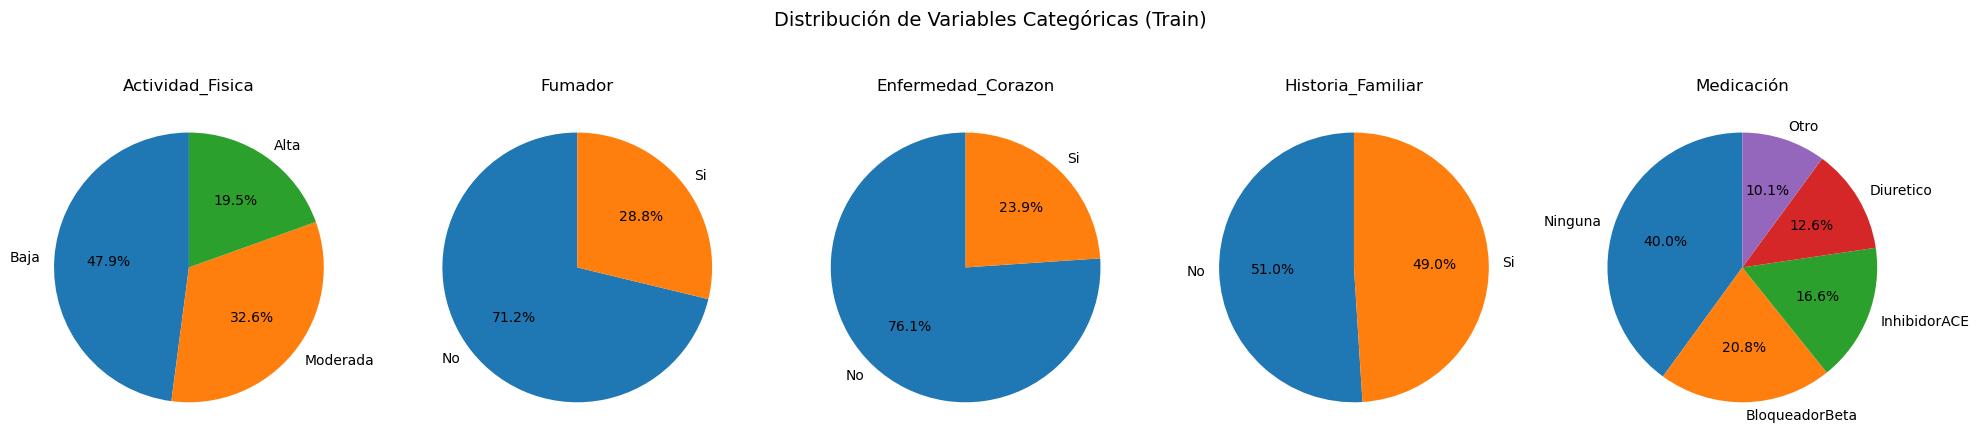

In [152]:
#cat_Ordinal = ['Actividad_Fisica']
#cat_binarias = ['Fumador','Enfermedad_Corazon','Historia_Familiar']
#cat_nominal = ['Medicación']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(cat_Ordinal + cat_binarias + cat_nominal):
    counts = X_train[col].value_counts()
    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(col)

plt.suptitle('Distribución de Variables Categóricas (Train)', fontsize=14)
plt.tight_layout()
plt.show()

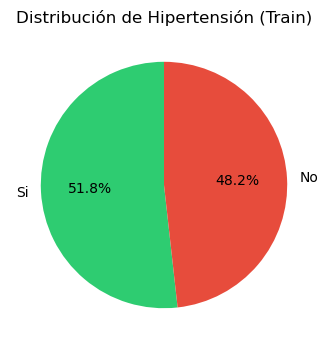

In [149]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = y_train.value_counts()
ax.pie(counts, labels=counts.index, autopct='%1.1f%%', 
       colors=['#2ecc71', '#e74c3c'], startangle=90)
ax.set_title('Distribución de Hipertensión (Train)')
plt.show()

<div style="
background:#d3f9d8;
border-left:6px solid #2b8a3e;
padding:16px;
border-radius:8px;
margin:12px 0;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#1b5e20;">✔ Resultado</b><br>
Se analizan las distribuciónes de todas las variables categóricas y Target para concluir que:
- Aunque las variables Fumador y enfermedad son las variablas mas desbalanceadas, sus respectivas distribuciones son representativas del problema y no requieren de algo ajuste o transformación
- Medicación tambíen tiene diversas proporciones de los datos, pero ninguna de ellas son lo suficientemente baja como por ejemplo la categoria <b>Otros</b> como para que amerite alguna imputación o transformación.
- Tan Historial familiar y como Hipertención(target) están casi perfectamente distribuidas 50/50 lo cual es bueno para el entranmiento ya que no se tendrán sesgos por este lado.

</div>

## Distribución de variables numéricas:

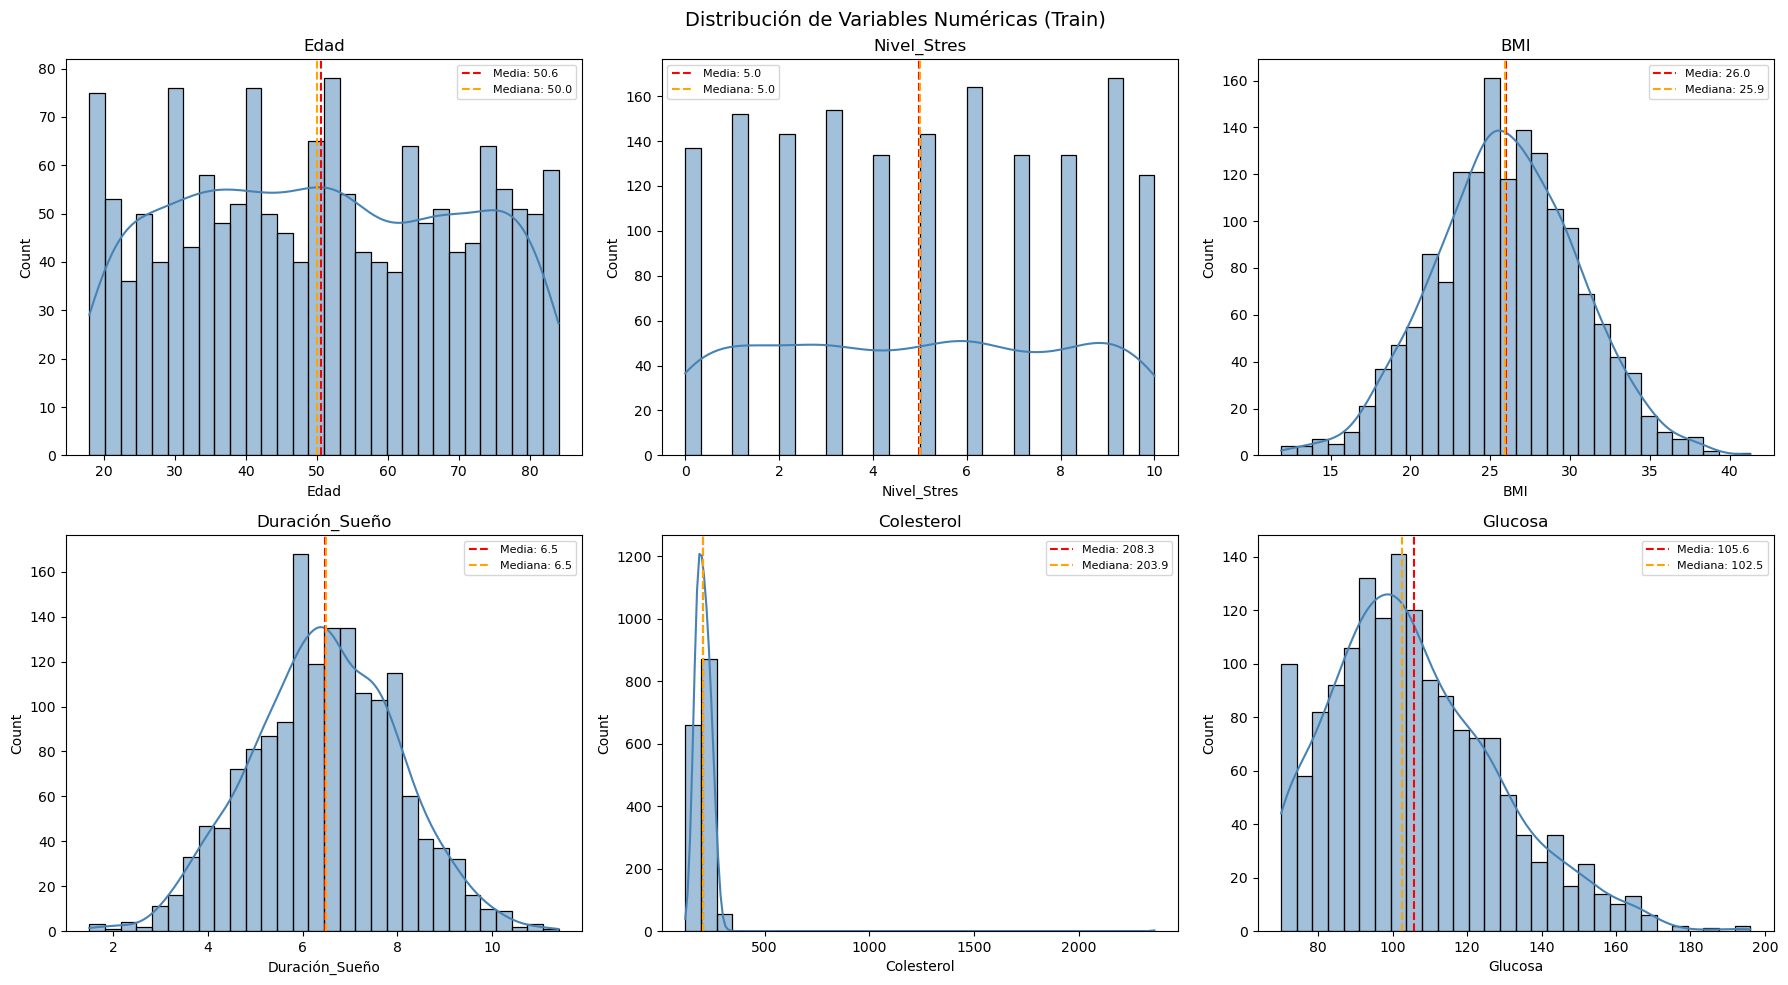

In [154]:
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(numericas):
    ax = axes[i // 3, i % 3]
    sns.histplot(X_train[col], bins=30, kde=True, ax=ax, color='steelblue')
    ax.axvline(X_train[col].mean(), color='red', linestyle='--', label=f'Media: {X_train[col].mean():.1f}')
    ax.axvline(X_train[col].median(), color='orange', linestyle='--', label=f'Mediana: {X_train[col].median():.1f}')
    ax.set_title(col, fontsize=12)
    ax.legend(fontsize=8)

plt.suptitle('Distribución de Variables Numéricas (Train)', fontsize=14)
plt.tight_layout()
plt.show()

<div style="
background:#d3f9d8;
border-left:6px solid #2b8a3e;
padding:16px;
border-radius:8px;
margin:12px 0;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#1b5e20;">✔ Resultado</b><br>
- Edad ->  Distribución aproximadamente uniforme, con varios picos, pero en general tiene muy buena simetría debido a la media de 50.6 y mediana 50
- No nivel_stres -> Muy buena distribución, muy uniforme y simetría. Esto se aprecia fácilmente con la curva de densidad que se ve sobre la gráfica.
- BMI -> Tiene una distribución gausiana (campana de Gauss) , una distribución normal.
- Duración del sueño -> Tambíen tiene una distribución normal.
- Colesterol -> <b>Claramente la distribución se ve afectada por los outliners. Se sigue afirmando que se realizará una eliminación de estos datos ya que representan menos del 1% del total de los datos y además son valores clínicamente imposibles según la literatura médica consultada (AHA/ACC, NCBI/NIH)</b>
- Glucosa -> Tiene una distribución normal aunque un poco sesgada hacia datos con glucosa Altos, <b>se sigue afirmando que se tomará la decisión de aplicar RobustScaler para que el modelo KNN se comporte mejor a datos extremos</b>

</div>

## Matriz de correlación

Aqui realizo un análisis de las correlaciones entre las variables numéricas unicamente:

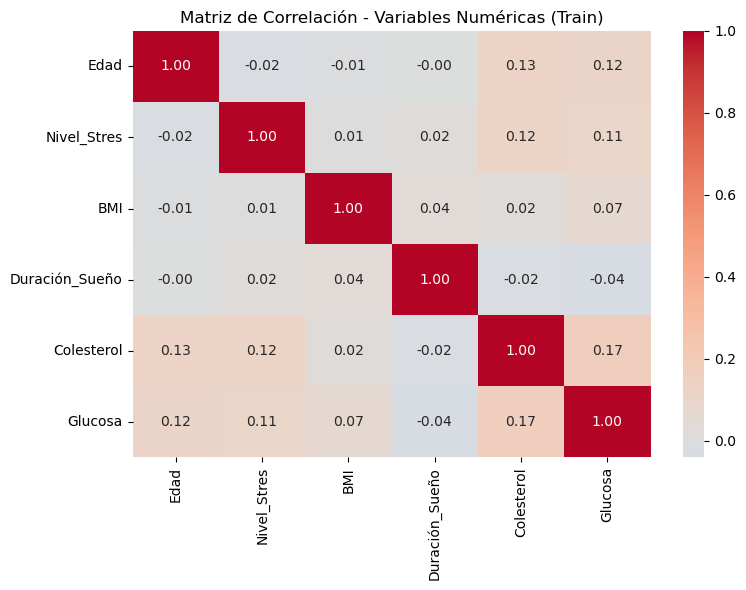

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = X_train[numericas].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Matriz de Correlación - Variables Numéricas (Train)')
plt.tight_layout()
plt.show()

<div style="
background:#d3f9d8;
border-left:6px solid #2b8a3e;
padding:16px;
border-radius:8px;
margin:12px 0;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#1b5e20;">✔ Resultado</b><br>
Se puede concluir que al analizar la matriz de correlación se evidencia que las correlaciones entre las variables están por debajo del umbral 0.8, incluso valorer cercanos a 0 por ende no es necesario eliminar alguna variable.

</div>

## Numéricas vs Target

Estas gráficas nos ayudan a ver si los pacientes hipertensos tienen valores diferentes a los no hipertensos en cada variable:

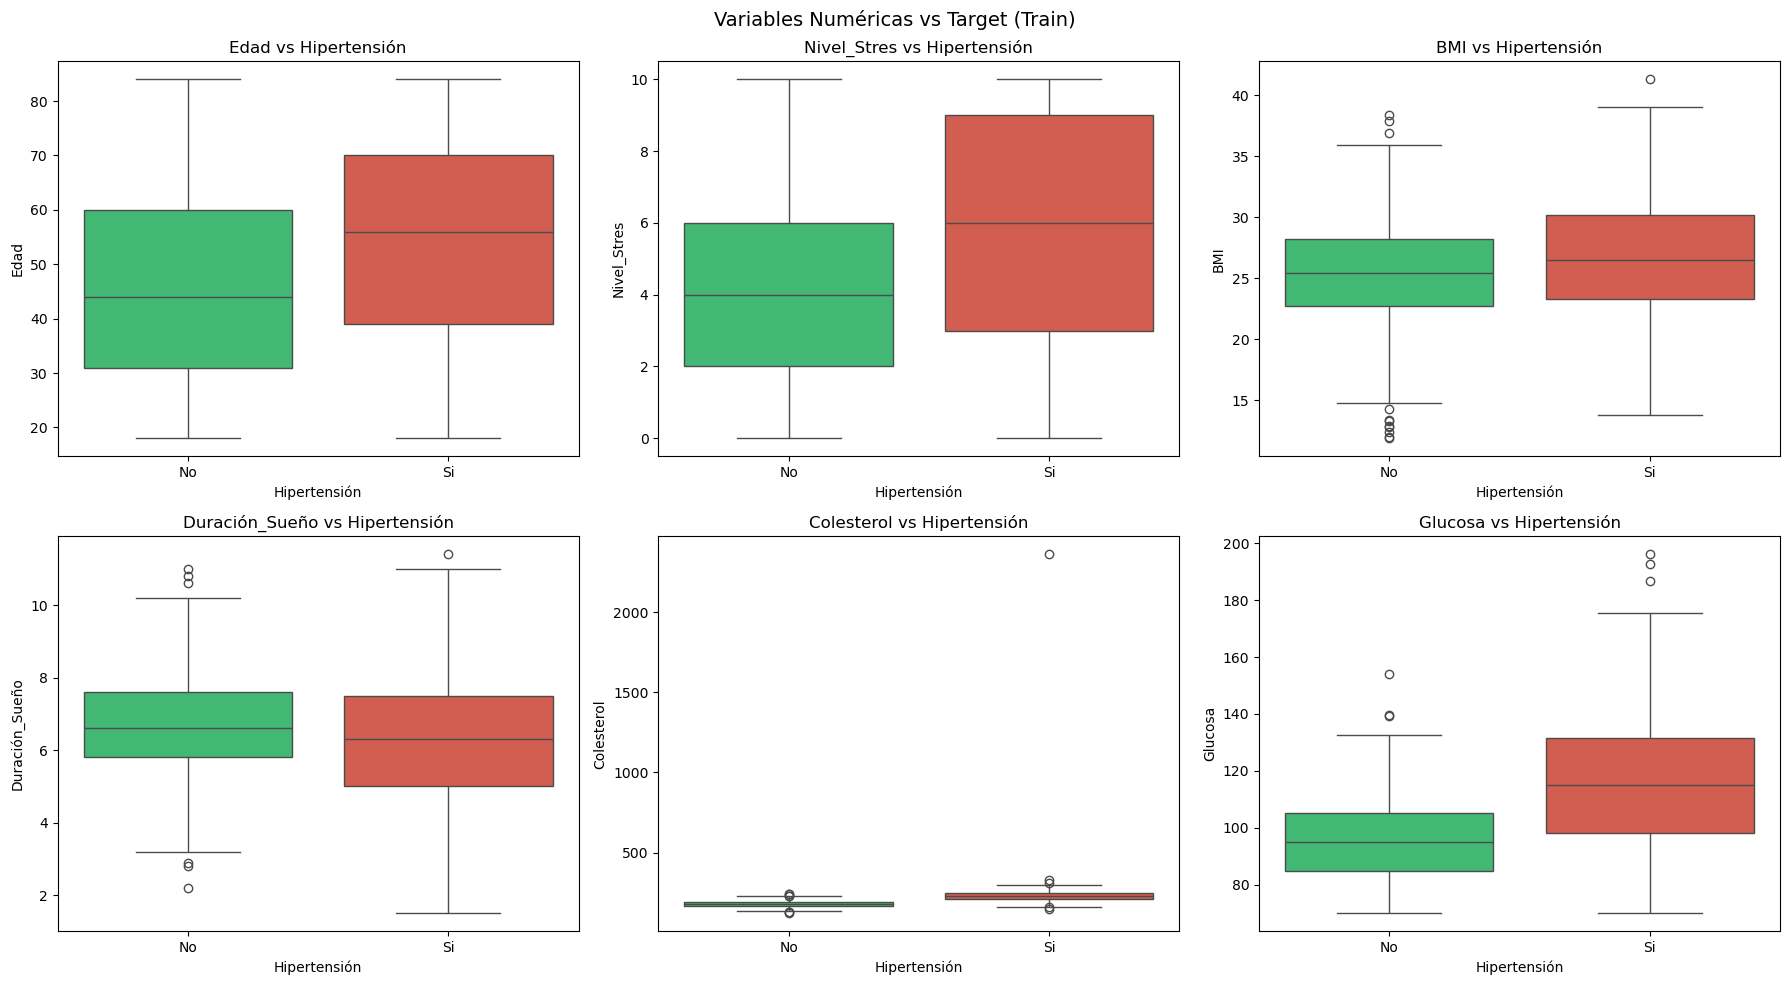

In [ ]:
 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(numericas):
    ax = axes[i // 3, i % 3]
    sns.boxplot(x=y_train, y=X_train[col], ax=ax, hue=y_train, palette=['#2ecc71', '#e74c3c'], legend=False)
    ax.set_title(f'{col} vs Hipertensión')
    ax.set_xlabel('Hipertensión')

plt.suptitle('Variables Numéricas vs Target (Train)', fontsize=14)
plt.tight_layout()
plt.show()

<div style="
background:#d3f9d8;
border-left:6px solid #2b8a3e;
padding:16px;
border-radius:8px;
margin:12px 0;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#1b5e20;">✔ Resultado</b><br>
Con estas gráficas podemos saber cual son las variables que muy posiblemente sean las más importante para los modelos a la hora de predecir si una persona puede o no tener hipertención. Al observarlas podemos evidenciar que:
- Edad -> Entre más años tenga una persona más probable es que tenga hipertención. Parece ser un predictor importante.
- <b>Nivel_stres -> Entre mayor sea el nivel de stres por encima de aproximadamente 6 entonces es más probable que sufrir hipertención</b>
- BMI -> Parece ser que el indice de masa corporal de la persona por si solo no es tan discriminante para identificar una posible razón de hipertención
- Duración del sueño -> Observamos lo mimo que el BMI, no parece ser un factor relevante.
- <b>Colesterol -> Nuevamente los outliners extremos o anómalos no nos permiten ver como realmente se comportan estos datos con el target, aunque se podría alcanzar a visualizar una leve diferencia en las cajas mostrando que posiblemente un alto nivel de colesterol puede ser un factor de un indicio de hipertención.</b>
- <b>Glucosa -> Vemos que valores por encima de aproximadamente 110 resulta en un factor positivo para hipertención. Parece ser una variabla muy importe para la predicción.</b>
</div>

## Categóricas vs Target

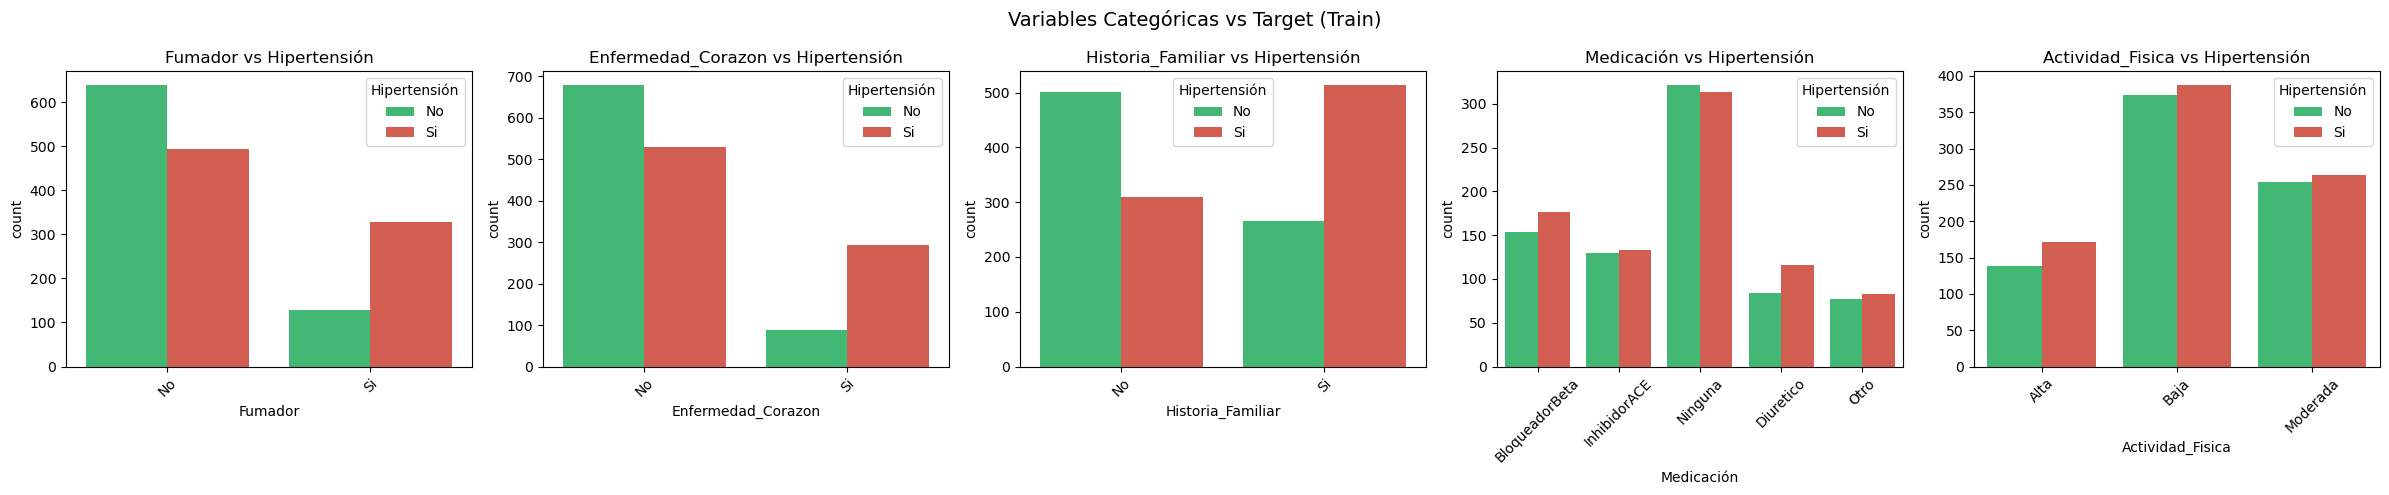

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

train_temp = X_train.copy()
train_temp['Hipertension'] = y_train.values

for i, col in enumerate(cat_binarias + cat_nominal + cat_Ordinal):
    sns.countplot(x=col, hue='Hipertension', data=train_temp, ax=axes[i],
                  palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{col} vs Hipertensión')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Hipertensión')

plt.suptitle('Variables Categóricas vs Target (Train)', fontsize=14)
plt.tight_layout()
plt.show()

<div style="
background:#d3f9d8;
border-left:6px solid #2b8a3e;
padding:16px;
border-radius:8px;
margin:12px 0;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#1b5e20;">✔ Resultado</b><br>
Con estas gráficas podemos saber cual son las variables categóricas que muy posiblemente sean las más importante para los modelos a la hora de predecir si una persona puede o sufrir hipertención.
- Fumador -> Según la gráfica podemos observar <b>claramente que existe una relación de peso si la persona fuma o no</b> para predecir hipertención
- Enfermedad del corazón -> Prácticamente el mismo patrón proporcional que Fumador, parece ser <b>muy importante a la hora de predecir hipertención</b>.
- Historial familiar -> También parece ser un <b>factor muy importante</b> para predecir la hipertención.
- Medicación -> Se observa una proporción uniforme entre las 5 categorias, aunquen podríamos estimar que para el modelo final puede ser mas importante si la persona tiene <b>medicación Diuretico, mas sin embargo es posible que Medicación no sea una buena predictora</b>
- Actividad física -> Se observa un patrón muy uniforme, no hay diferencias notables en las proporciones, no parece ser una variable tan importante para estimar la hipertención.
</div>

# Limpieza y preparación de los datos:

A continuación se creará una función de limpienza y pipeline para esto proceso, sustentado sobre las conclusiones del EDA. Listo a continuación un resumen de las conclusiones:
- Eliminar la variable Ingesta de sal
- Eliminar datos anómalos clinicamente improbables
- Incluir en el pipeline un imputador para datos futuros que vengan vacios. Aunque en este caso no teniamos este escenario puede que en producción suceda entonces me aseguro de esto de una vez.



Crearé una función `limpiar_datos` para poder reutilizarla para cualquier escenario, sobre todo para el conjunto test y tamìen si se llega a producción.

In [ ]:
def limpiar_datos(X):
    X_clean = X.copy()

    if 'Ingesta_Sal' in X_clean.columns:
        X_clean = X_clean.drop(columns = ['Ingesta_Sal'])

    mascara = train['Colesterol'] <= 500
    train = train[mascara]

In [ ]:
def limpiar_datos(X, y=None):
    """
    Aplica reglas de negocio clínicas para limpiar datos.
    Se creó esta función ya que más adelante se tiene que hacer el mismo proceso para Test.
    Y tambíen para datos futuros.
    
    Reglas aplicadas:
    1. Eliminar columna Ingesta_Sal (inconsistente con diccionario médico)
    2. Eliminar registros con Colesterol > 500 mg/dL (clínicamente imposible,según guías AHA/ACC)
    
    Parámetros:
    X: DataFrame con variables descriptoras
    y: Datos de variable target, para sincronizar las filas eliminadas.
    
    Retorna:
    X_limpio, y_limpio (si se pasó y)
    X_limpio (si no se pasó y, para predicción en producción)
    """
    X_clean = X.copy()
    
    if 'Ingesta_Sal' in X_clean.columns:
        X_clean = X_clean.drop(columns=['Ingesta_Sal'])
    
    mask = X_clean['Colesterol'] <= 500
    n_eliminados = (~mask).sum()
    if n_eliminados > 0:
        print(f"{n_eliminados} registros eliminados (Colesterol > 500)")
    
    X_clean = X_clean[mask]
    
    if y is not None:
        y_clean = y[mask]
        return X_clean, y_clean
    
    return X_clean

# 10. COSAS

In [ ]:
2. Aplicar la limpieza:
python# Limpiar train (X e y deben estar juntos para eliminar filas sincronizadamente)
train_limpio = limpiar_datos(
    X_train.assign(Hipertension=y_train)
)
X_train = train_limpio.drop(columns=['Hipertension'])
y_train = train_limpio['Hipertension']

# Limpiar test (misma función, misma regla)
test_limpio = limpiar_datos(
    X_test.assign(Hipertension=y_test)
)
X_test = test_limpio.drop(columns=['Hipertension'])
y_test = test_limpio['Hipertension']

print(f"\nTrain final: {X_train.shape[0]} registros")
print(f"Test final:  {X_test.shape[0]} registros")




3. Pipeline de transformación (sklearn):
pythonfrom sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Definir columnas por tipo
num_features = ['Edad', 'Nivel_Stres', 'Colesterol', 
                'Duración_Sueño', 'BMI', 'Glucosa']

cat_ordinal_features = ['Actividad_Fisica']

cat_nominal_features = ['Medicación', 'Historia_Familiar', 
                        'Fumador', 'Enfermedad_Corazon']

# Preprocesador
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('ord', OrdinalEncoder(categories=[['Baja', 'Moderada', 'Alta']]), 
            cat_ordinal_features),
    ('cat', OneHotEncoder(drop='if_binary', sparse_output=False), 
            cat_nominal_features)
], remainder='drop')  # drop ignora columnas no listadas (como Ingesta_Sal)





4. Pipeline completo con modelo:
python# Para Árbol de Decisión
pipe_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=77))
])

# Para KNN
pipe_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])








5. Uso a futuro con datos nuevos:
python# Llega un paciente nuevo
nuevo_paciente = pd.DataFrame({
    'Edad': [55], 'Nivel_Stres': [7], 'Colesterol': [245],
    'Duración_Sueño': [5.5], 'BMI': [31.2], 'Glucosa': [130],
    'Actividad_Fisica': ['Baja'], 'Medicación': ['Ninguna'],
    'Historia_Familiar': ['Si'], 'Fumador': ['No'],
    'Enfermedad_Corazon': ['No'], 'Ingesta_Sal': [8.5]
})

# Paso 1: limpiar (misma función)
nuevo_limpio = limpiar_datos(nuevo_paciente)

# Paso 2: predecir (el pipeline hace todo el preprocesamiento internamente)
prediccion = pipe_tree.predict(nuevo_limpio)
print(f"Riesgo de hipertensión: {prediccion[0]}")

In [72]:
resumen = pd.DataFrame({
    'tipo_dtype': data.dtypes,
    'num_unicos': data.nunique(),
    'nulos': data.isnull().sum(),
    'pct_nulos': (data.isnull().sum() / len(data) * 100).round(2),
    'min': data.min(numeric_only=True),
    'max': data.max(numeric_only=True),
    'ejemplo_valores': [data[col].dropna().unique()[:5].tolist() for col in data.columns],
    'posible_tipo': [
        'Categorica' if data[col].nunique() <= 10 
        else 'Binaria' if data[col].nunique() == 2 
        else 'Numerica' 
        for col in data.columns
    ]
})
resumen

,tipo_dtype,num_unicos,nulos,pct_nulos,min,max,ejemplo_valores,posible_tipo
Actividad_Fisica,object,3,0,0.0,NaN,NaN,"[69, 32, 78, 38, 41]",Numerica
BMI,float64,236,0,0.0,11.9,41.9,"[8.0, 11.7, 9.5, 10.0, 9.8]",Numerica
Colesterol,float64,1006,0,0.0,121.2,2360.0,"[9, 10, 3, 1, 0]",Numerica
Duración_Sueño,float64,88,0,0.0,1.5,11.4,"[242.4, 177.2, 193.0, 268.1, 175.3]",Numerica
Edad,int64,67,0,0.0,18.0,84.0,"[6.4, 5.4, 7.1, 4.2, 5.8]",Numerica
Enfermedad_Corazon,object,2,0,0.0,NaN,NaN,"[25.8, 23.4, 18.7, 22.1, 16.2]",Numerica
Fumador,object,2,0,0.0,NaN,NaN,"[Ninguna, InhibidorACE, Otro, BloqueadorBeta, ...",Categorica
Glucosa,float64,745,0,0.0,70.0,196.1,"[Si, No]",Categorica
Hipertension,object,2,0,0.0,NaN,NaN,"[Baja, Moderada, Alta]",Categorica
Historia_Familiar,object,2,0,0.0,NaN,NaN,"[No, Si]",Categorica


In [99]:
resumen = pd.DataFrame({
    'tipo_dtype': train.dtypes,
    'num_unicos': train.nunique(),
    'nulos': train.isnull().sum(),
    'pct_nulos': (train.isnull().sum() / len(train) * 100).round(2),
    'ejemplo_valores': [train[col].dropna().unique()[:5].tolist() for col in train.columns],
    'posible_tipo': [
        'Binaria' if train[col].nunique() == 2
        else 'Categórica' if train[col].nunique() <= 10
        else 'Numérica continua'
        for col in train.columns
    ]
})
resumen

,tipo_dtype,num_unicos,nulos,pct_nulos,ejemplo_valores,posible_tipo
Edad,int64,67,0,0.0,"[37, 34, 75, 50, 49]",Numérica continua
Ingesta_Sal,float64,117,0,0.0,"[6.7, 9.9, 7.3, 6.8, 6.5]",Numérica continua
Nivel_Stres,int64,11,0,0.0,"[3, 2, 7, 0, 4]",Numérica continua
Colesterol,float64,905,0,0.0,"[194.7, 192.8, 209.4, 213.3, 189.8]",Numérica continua
Duración_Sueño,float64,86,0,0.0,"[8.6, 4.8, 5.9, 4.5, 5.7]",Numérica continua
BMI,float64,231,0,0.0,"[21.1, 21.4, 35.2, 22.5, 21.0]",Numérica continua
Medicación,object,5,0,0.0,"[BloqueadorBeta, InhibidorACE, Ninguna, Diuret...",Categórica
Historia_Familiar,object,2,0,0.0,"[No, Si]",Binaria
Actividad_Fisica,object,3,0,0.0,"[Alta, Baja, Moderada]",Categórica
Fumador,object,2,0,0.0,"[No, Si]",Binaria


## Detección de outliners:

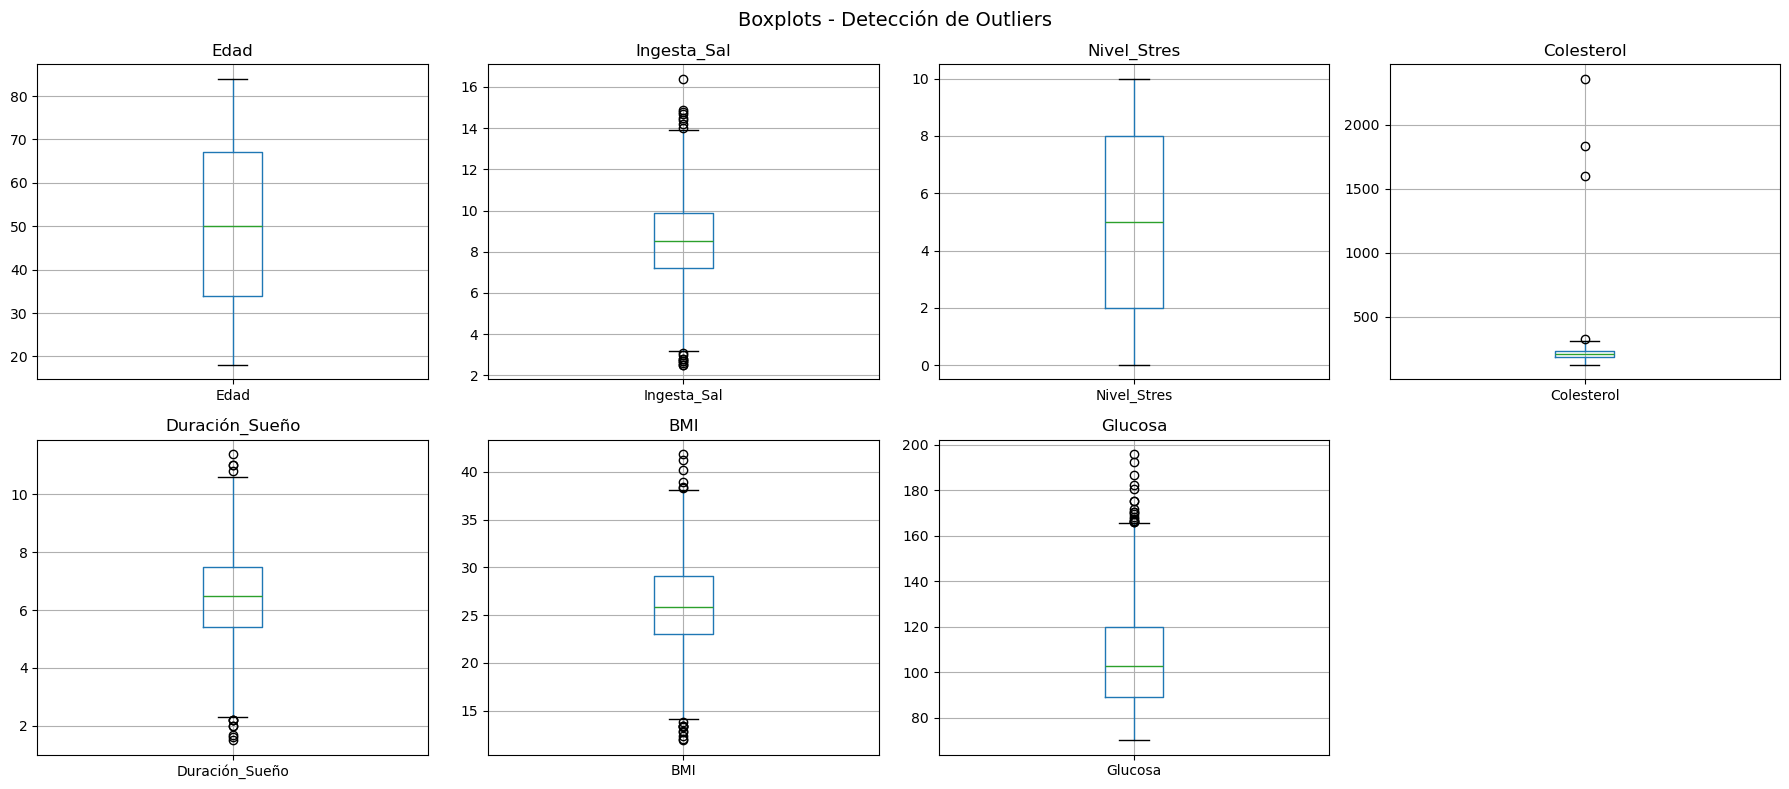

In [74]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
num_cols = ['Edad', 'Ingesta_Sal', 'Nivel_Stres', 'Colesterol',
            'Duración_Sueño', 'BMI', 'Glucosa']

for i, col in enumerate(num_cols):
    ax = axes[i // 4, i % 4]
    data.boxplot(column=col, ax=ax)
    ax.set_title(col)

axes[1, 3].axis('off')
plt.suptitle('Boxplots - Detección de Outliers', fontsize=14)
plt.tight_layout()
plt.show()

In [75]:
# Colesterol: outliers extremos
print("=== Outliers extremos en Colesterol ===")
print(data[data['Colesterol'] > 500][['Colesterol']])
print(f"\nEstadísticas normales de Colesterol (sin outliers > 500):")
print(data[data['Colesterol'] <= 500]['Colesterol'].describe())

=== Outliers extremos en Colesterol ===
     Colesterol
12       2360.0
16       1597.0
196      1835.0

Estadísticas normales de Colesterol (sin outliers > 500):
count    1983.000000
mean      206.917499
std        33.445252
min       121.200000
25%       181.250000
50%       204.300000
75%       231.700000
max       326.300000
Name: Colesterol, dtype: float64


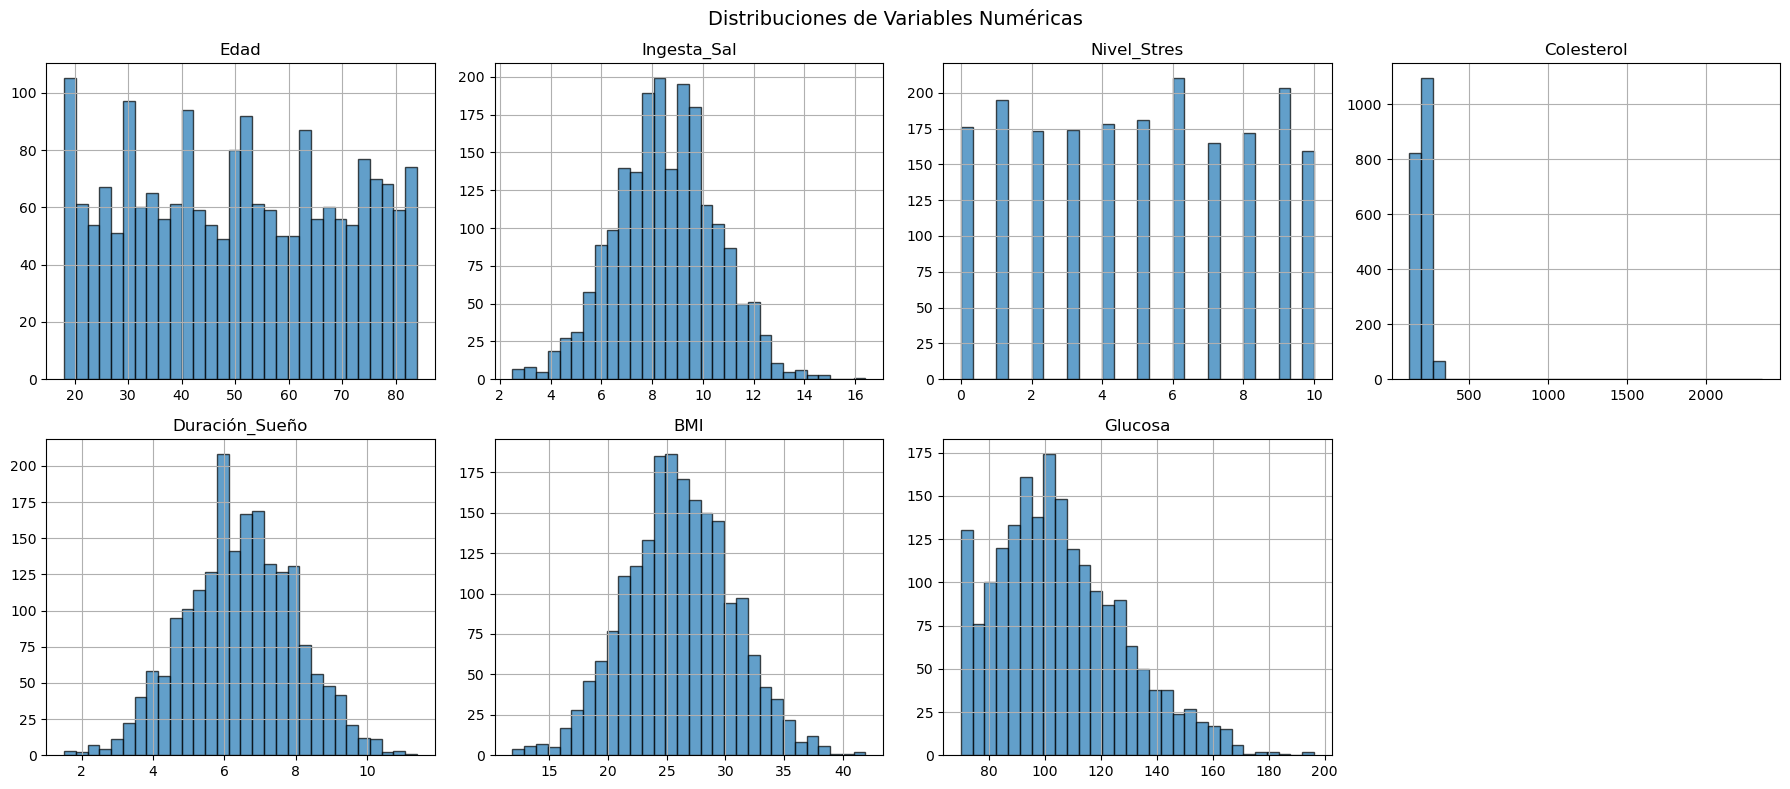

In [76]:
# Distribución de variables numéricas
%matplotlib inline
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(num_cols):
    ax = axes[i // 4, i % 4]
    data[col].hist(bins=30, ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(col)
axes[1, 3].axis('off')
plt.suptitle('Distribuciones de Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

In [77]:

num_features = ['Edad', 'Ingesta_Sal', 'Nivel_Stres', 'Colesterol', 
                'Duración_Sueño', 'BMI', 'Glucosa']

cat_nominal_features = ['Medicación', 'Historia_Familiar', 'Fumador', 'Enfermedad_Corazon']


cat_ordinal_features = ['Actividad_Fisica']

Tiene un orden natural (Baja < Moderada < Alta),
  por lo que se codifica como 0, 1, 2 respetando esa relación ordinal.

# Pipiline

In [78]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_features),
        ('cat_nominal', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='error'), 
         cat_nominal_features),
        ('cat_ordinal', OrdinalEncoder(categories=[['Baja', 'Moderada', 'Alta']]), 
         cat_ordinal_features)
    ],
    remainder='drop'
)

X_train_transformed = preprocessor.fit_transform(train)
print(f"Columnas transformadas: {X_train_transformed.shape[1]}")

ohe_names = preprocessor.named_transformers_['cat_nominal'].get_feature_names_out(cat_nominal_features).tolist()
all_feature_names = num_features + ohe_names + cat_ordinal_features
print(f"Nombres de features: {all_feature_names}")

Columnas transformadas: 15
Nombres de features: ['Edad', 'Ingesta_Sal', 'Nivel_Stres', 'Colesterol', 'Duración_Sueño', 'BMI', 'Glucosa', 'Medicación_Diuretico', 'Medicación_InhibidorACE', 'Medicación_Ninguna', 'Medicación_Otro', 'Historia_Familiar_Si', 'Fumador_Si', 'Enfermedad_Corazon_Si', 'Actividad_Fisica']


# Árbol


In [79]:
pipe_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=SEED))
])

param_grid_tree = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [4, 6, 8, 10, 12],
    'classifier__min_samples_split': [3, 4, 5]
}

grid_tree = GridSearchCV(
    pipe_tree,
    param_grid_tree,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)

grid_tree.fit(X_train, y_train)

print("=== Árbol de Decisión - GridSearchCV ===")
print(f"Mejores hiperparámetros: {grid_tree.best_params_}")
print(f"Mejor accuracy (CV): {grid_tree.best_score_:.4f}")

NameError: name 'SEED' is not defined

In [ ]:
best_criterion = grid_tree.best_params_['classifier__criterion']
best_min_samples = grid_tree.best_params_['classifier__min_samples_split']

pipe_tree_rules = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        criterion=best_criterion,
        max_depth=3,
        min_samples_split=best_min_samples,
        random_state=SEED
    ))
])
pipe_tree_rules.fit(X_train, y_train)

In [ ]:
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    pipe_tree_rules.named_steps['classifier'],
    feature_names=all_feature_names,
    class_names=['No Hipertensión', 'Sí Hipertensión'],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)
ax.set_title('Árbol de Decisión (Profundidad = 3)', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
def limpiar_datos(df):
    """
    Aplica reglas de negocio clínicas para limpiar datos.
    Reutilizable para train, test y datos nuevos a futuro.
    
    Reglas basadas en literatura médica:
    - Colesterol total > 500 mg/dL: clínicamente imposible 
      (incluso en hipercolesterolemia familiar homocigota 
       los niveles rara vez superan este umbral - NCBI/NIH)
    """
    df_clean = df.copy()
    
    # Marcar registros inválidos
    mask_invalido = df_clean['Colesterol'] > 500
    n_invalidos = mask_invalido.sum()
    
    if n_invalidos > 0:
        print(f"⚠️ {n_invalidos} registros con Colesterol > 500 mg/dL eliminados (error de captura)")
    
    df_clean = df_clean[~mask_invalido]
    
    return df_clean